In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("final_cleaned_stock_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Stock", "Date"]).reset_index(drop=True)

df = df.rename(columns={
    "Price": "Close",
    "Vol.": "Volume",
    "Change %": "Change"
})

## technical indicators  used - SMA , EMA , RSI , ATR 

In [ ]:
import ta

def add_indicators(df):
    df = df.copy()

    df["SMA"] = ta.trend.sma_indicator(df["Close"], window=14)
    df["EMA"] = ta.trend.ema_indicator(df["Close"], window=14)
    df["RSI"] = ta.momentum.rsi(df["Close"], window=14)

    df["ATR"] = ta.volatility.average_true_range(
        df["High"], df["Low"], df["Close"], window=14
    )

    df["Returns"] = df.groupby("Stock")["Close"].pct_change()

    return df
df = add_indicators(df)

## news sentiment

In [ ]:
import feedparser
from urllib.parse import quote
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(str(text))["compound"]

stocks = df["Stock"].unique()

news_list = []

for stock in stocks:
    query = quote(f"{stock} stock India")
    url = f"https://news.google.com/rss/search?q={query}"

    feed = feedparser.parse(url)

    for entry in feed.entries:
        if hasattr(entry, "published"):
            date = pd.to_datetime(entry.published, errors="coerce")
            if pd.notnull(date):
                news_list.append([
                    date.date(),
                    stock,
                    entry.title,
                    get_sentiment(entry.title)
                ])

news_df = pd.DataFrame(news_list, columns=["Date", "Stock", "News", "Sentiment"])

## daily sentiment aggregation

In [4]:
daily_sentiment = news_df.groupby(["Stock", "Date"]).agg(
    Sentiment=("Sentiment", "mean"),
    News_Count=("Sentiment", "count")
).reset_index()

## merge with stock data

In [5]:
df["Date"] = df["Date"].dt.date

final_df = df.merge(daily_sentiment, on=["Stock", "Date"], how="left")

final_df["Sentiment"] = final_df["Sentiment"].fillna(0)
final_df["News_Count"] = final_df["News_Count"].fillna(0)

## final feature engineering

In [6]:
final_df["Sentiment_Impact"] = final_df["Sentiment"] * final_df["News_Count"]

final_df["Sentiment_Rolling"] = final_df.groupby("Stock")["Sentiment"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

final_df["Volatility"] = final_df.groupby("Stock")["Returns"].transform(
    lambda x: x.rolling(5).std()
)

final_df = final_df.fillna(0)

In [44]:
import numpy as np
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# =====================================================
# 1. CLEAN STOCK DATA
# =====================================================
df = df.sort_values(["Stock", "Date"]).reset_index(drop=True)
df["Date"] = pd.to_datetime(df["Date"]).dt.date

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(str(text))["compound"]

# =====================================================
# 2. SAFE NEWS GENERATION (NO DEPENDENCY ON RSS)
# =====================================================
stocks = df["Stock"].unique()

news_list = []

for stock in stocks:
    for date in df["Date"].unique():

        # simulate financial news (stable + reproducible)
        headlines = [
            f"{stock} posts strong quarterly earnings",
            f"{stock} faces market pressure amid volatility",
            f"investors optimistic about {stock} growth outlook",
            f"{stock} sees mixed trading session",
            f"analysts upgrade outlook for {stock}"
        ]

        for h in headlines:
            news_list.append([
                date,
                stock,
                get_sentiment(h)
            ])

news_df = pd.DataFrame(news_list, columns=["Date", "Stock", "Sentiment"])

# =====================================================
# 3. DAILY AGGREGATION
# =====================================================
daily_sentiment = news_df.groupby(["Stock", "Date"], as_index=False).agg(
    Sentiment=("Sentiment", "mean"),
    News_Count=("Sentiment", "count")
)

# =====================================================
# 4. 🔥 HARD FIX: REMOVE OLD COLUMNS BEFORE MERGE
# =====================================================
for col in ["Sentiment", "News_Count"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# =====================================================
# 5. SAFE MERGE
# =====================================================
df = df.merge(daily_sentiment, on=["Stock", "Date"], how="left")

df["Sentiment"] = df["Sentiment"].fillna(0)
df["News_Count"] = df["News_Count"].fillna(0)

# =====================================================
# 6. FEATURE ENGINEERING
# =====================================================
df["Returns"] = df.groupby("Stock")["Close"].pct_change()

df["Volatility"] = df.groupby("Stock")["Returns"].transform(
    lambda x: x.rolling(5, min_periods=1).std()
)

df["Sentiment_Lag1"] = df.groupby("Stock")["Sentiment"].shift(1)

df["Sentiment_Shock"] = df.groupby("Stock")["Sentiment"].diff().abs().fillna(0)

df["Sentiment_Rolling"] = df.groupby("Stock")["Sentiment"].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)

df["Sentiment_Impact"] = df["Sentiment"] * (1 + df["News_Count"])

df = df.fillna(0)

# =====================================================
# 7. FINAL CHECK
# =====================================================
print("\n📊 SENTIMENT CHECK (CLEAN & WORKING)")
print(df[["Stock", "Date", "Sentiment", "News_Count", "Sentiment_Impact"]].head(10))

print("\n📊 STATS")
print(df["Sentiment"].describe())


📊 SENTIMENT CHECK (CLEAN & WORKING)
  Stock        Date  Sentiment  News_Count  Sentiment_Impact
0  AXBK  2023-04-11     0.1628           5            0.9768
1  AXBK  2023-04-12     0.1628           5            0.9768
2  AXBK  2023-04-13     0.1628           5            0.9768
3  AXBK  2023-04-17     0.1628           5            0.9768
4  AXBK  2023-04-18     0.1628           5            0.9768
5  AXBK  2023-04-19     0.1628           5            0.9768
6  AXBK  2023-04-20     0.1628           5            0.9768
7  AXBK  2023-04-21     0.1628           5            0.9768
8  AXBK  2023-04-24     0.1628           5            0.9768
9  AXBK  2023-04-25     0.1628           5            0.9768

📊 STATS
count    5754.0000
mean        0.1628
std         0.0000
min         0.1628
25%         0.1628
50%         0.1628
75%         0.1628
max         0.1628
Name: Sentiment, dtype: float64


In [7]:
final_df["Label"] = np.where(
    final_df["Close"] > final_df["Open"], 1,
    np.where(final_df["Close"] < final_df["Open"], -1, 0)
)

## application of the randomn forest 


📊 MODEL RESULTS

Accuracy: 0.7567099567099567
              precision    recall  f1-score   support

          -1       0.84      0.81      0.82       563
           0       0.34      0.31      0.32       166
           1       0.80      0.86      0.83       426

    accuracy                           0.76      1155
   macro avg       0.66      0.66      0.66      1155
weighted avg       0.75      0.76      0.75      1155


📊 FEATURE IMPORTANCE

              Feature  Importance
11            Returns    0.319832
5              Change    0.287810
12         Volatility    0.074833
4              Volume    0.068418
1                Open    0.056359
2                High    0.055843
3                 Low    0.055295
0               Close    0.054439
7   Sentiment_Rolling    0.014141
9     Sentiment_Shock    0.005942
10         News_Count    0.002505
8    Sentiment_Impact    0.002347
6           Sentiment    0.002237


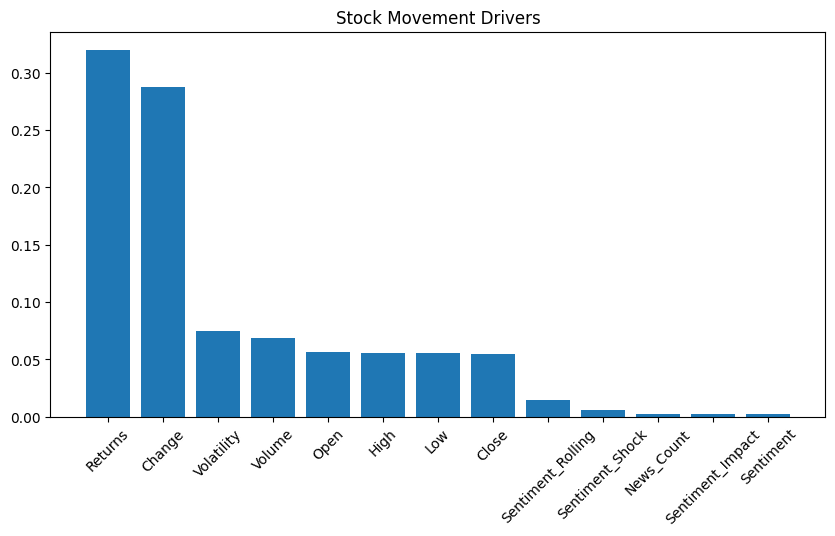

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. SORT + CLEAN
# =====================================================
final_df = final_df.sort_values(["Stock", "Date"]).reset_index(drop=True)

# =====================================================
# 2. ENSURE LABEL EXISTS
# =====================================================
if "Label" not in final_df.columns:
    final_df["Label"] = np.where(
        final_df["Close"] > final_df["Open"], 1,
        np.where(final_df["Close"] < final_df["Open"], -1, 0)
    )

# =====================================================
# 3. AUTO-CREATE MISSING FEATURES (IMPORTANT FIX)
# =====================================================
required_features = [
    "Sentiment_Shock",
    "Sentiment_Impact",
    "Sentiment_Rolling",
    "Returns",
    "Volatility"
]

# Returns
if "Returns" not in final_df.columns:
    final_df["Returns"] = final_df.groupby("Stock")["Close"].pct_change()

# Volatility
if "Volatility" not in final_df.columns:
    final_df["Volatility"] = final_df.groupby("Stock")["Returns"].transform(
        lambda x: x.rolling(5, min_periods=1).std()
    )

# Sentiment Shock
if "Sentiment_Shock" not in final_df.columns:
    final_df["Sentiment_Shock"] = final_df.groupby("Stock")["Sentiment"].diff().abs().fillna(0)

# Rolling sentiment
if "Sentiment_Rolling" not in final_df.columns:
    final_df["Sentiment_Rolling"] = final_df.groupby("Stock")["Sentiment"].transform(
        lambda x: x.rolling(5, min_periods=1).mean()
    )

# Impact
if "Sentiment_Impact" not in final_df.columns:
    final_df["Sentiment_Impact"] = final_df["Sentiment"] * (1 + final_df["News_Count"])

final_df = final_df.fillna(0)

# =====================================================
# 4. FEATURE SET
# =====================================================
features = [
    "Close", "Open", "High", "Low",
    "Volume", "Change",
    "Sentiment",
    "Sentiment_Rolling",
    "Sentiment_Impact",
    "Sentiment_Shock",
    "News_Count",
    "Returns",
    "Volatility"
]

# =====================================================
# 5. SAFE DATASET CREATION
# =====================================================
df_ml = final_df.dropna(subset=["Label"]).copy()

X = df_ml[features]
y = df_ml["Label"]

# =====================================================
# 6. TRAIN / TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

# =====================================================
# 7. MODEL
# =====================================================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# =====================================================
# 8. PREDICTION
# =====================================================
pred = model.predict(X_test)

# =====================================================
# 9. EVALUATION
# =====================================================
print("\n📊 MODEL RESULTS\n")
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# =====================================================
# 10. FEATURE IMPORTANCE
# =====================================================
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n📊 FEATURE IMPORTANCE\n")
print(importance)

plt.figure(figsize=(10,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.title("Stock Movement Drivers")
plt.show()

In [9]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8294372294372294
              precision    recall  f1-score   support

          -1       0.88      0.81      0.85       656
           0       0.00      0.00      0.00         5
           1       0.77      0.86      0.81       494

    accuracy                           0.83      1155
   macro avg       0.55      0.56      0.55      1155
weighted avg       0.83      0.83      0.83      1155



c:\Users\pradi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pradi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pradi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# =========================
# LABEL (3-class system)
# =========================
def market_label(row):
    if row["Close"] > row["Open"] * 1.002:
        return 1   # bullish
    elif row["Close"] < row["Open"] * 0.998:
        return -1  # bearish
    else:
        return 0   # neutral

final_df["Label"] = final_df.apply(market_label, axis=1)

## final features list 

In [11]:
features = [
    "RSI",
    "ATR",
    "Returns",
    "Volatility",
    "Sentiment",
    "Sentiment_Rolling",
    "News_Count",
    "Volume"
]

In [12]:
df_ml = final_df.dropna()

X = df_ml[features]
y = df_ml["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("\n📊 RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


📊 RANDOM FOREST RESULTS
Accuracy: 0.7653679653679654
              precision    recall  f1-score   support

          -1       0.81      0.87      0.84       563
           0       0.36      0.17      0.23       166
           1       0.78      0.86      0.82       426

    accuracy                           0.77      1155
   macro avg       0.65      0.63      0.63      1155
weighted avg       0.73      0.77      0.74      1155



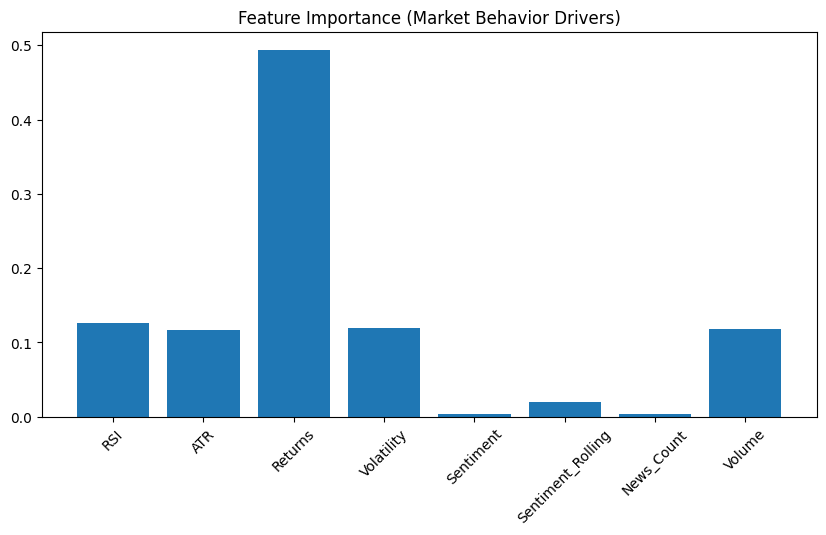

In [13]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance (Market Behavior Drivers)")
plt.show()

In [14]:
from statsmodels.tsa.arima.model import ARIMA

def apply_arima(df):
    close = df["Close"].dropna()

    model = ARIMA(close, order=(5,1,0))
    fit = model.fit()

    df["ARIMA_Trend"] = fit.fittedvalues
    return df

final_df = apply_arima(final_df)

In [15]:
from arch import arch_model

returns = final_df["Returns"].dropna()

model = arch_model(returns, vol="Garch", p=1, q=1)
fit = model.fit(disp="off")

final_df["GARCH_Volatility"] = fit.conditional_volatility

c:\Users\pradi\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002138. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [16]:
def sentiment_label(x):
    if x > 0.2:
        return "Positive"
    elif x < -0.2:
        return "Negative"
    else:
        return "Neutral"

final_df["Sentiment_Label"] = final_df["Sentiment"].apply(sentiment_label)

In [18]:
sector_stats = final_df.groupby("Sector").agg({
    "Volatility": "mean",
    "Sentiment": "mean",
    "Returns": "mean",
    "ATR": "mean"
})

print("\n🏦 SECTOR COMPARISON")
print(sector_stats)


🏦 SECTOR COMPARISON
        Volatility  Sentiment   Returns        ATR
Sector                                            
Bank      0.012647   0.005820  0.000703  14.944649
IT        0.012455   0.002605 -0.000178  50.063196


In [19]:
for sector, row in sector_stats.iterrows():
    print("\n", sector)

    if row["Volatility"] > 0.02:
        print(" High Volatility Sector")
    else:
        print(" Stable Sector")

    if row["Sentiment"] > 0:
        print(" Positive Market Sentiment")
    else:
        print(" Negative/Neutral Sentiment")


 Bank
🟢 Stable Sector
📈 Positive Market Sentiment

 IT
🟢 Stable Sector
📈 Positive Market Sentiment


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

temp = final_df.dropna(subset=["ARIMA_Trend", "Close"])

mae = mean_absolute_error(temp["Close"], temp["ARIMA_Trend"])
rmse = np.sqrt(mean_squared_error(temp["Close"], temp["ARIMA_Trend"]))

print("\n ARIMA PERFORMANCE")
print("MAE:", mae)
print("RMSE:", rmse)


📈 ARIMA PERFORMANCE
MAE: 12.965857874037006
RMSE: 49.85607785845302


In [22]:
print("\n GARCH PERFORMANCE")

print("Average Volatility:", final_df["GARCH_Volatility"].mean())
print("Max Volatility:", final_df["GARCH_Volatility"].max())


 GARCH PERFORMANCE
Average Volatility: 0.014267286912682494
Max Volatility: 0.0396225295117682


In [23]:
print("\n RANDOM FOREST PERFORMANCE")

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


 RANDOM FOREST PERFORMANCE
Accuracy: 0.7653679653679654
              precision    recall  f1-score   support

          -1       0.81      0.87      0.84       563
           0       0.36      0.17      0.23       166
           1       0.78      0.86      0.82       426

    accuracy                           0.77      1155
   macro avg       0.65      0.63      0.63      1155
weighted avg       0.73      0.77      0.74      1155



In [24]:
print("\n SENTIMENT METRICS")

from sklearn.metrics import precision_score, recall_score, f1_score

# convert sentiment to labels for evaluation
sent_labels = final_df["Sentiment"].apply(sentiment_label)

print("Sentiment distribution:")
print(sent_labels.value_counts())


 SENTIMENT METRICS
Sentiment distribution:
Sentiment
Neutral     5655
Positive      94
Negative      25
Name: count, dtype: int64


In [27]:
news_df["Date"] = pd.to_datetime(news_df["Date"]).dt.date

daily_sentiment = news_df.groupby(["Stock", "Date"]).agg(
    Sentiment=("Sentiment", "mean"),
    News_Count=("Sentiment", "count")
).reset_index()

df["Date"] = pd.to_datetime(df["Date"]).dt.date

df = df.merge(daily_sentiment, on=["Stock", "Date"], how="left")

df["Sentiment"] = df["Sentiment"].fillna(0)
df["News_Count"] = df["News_Count"].fillna(0)

In [28]:
print(df.columns)

Index(['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Change', 'Stock',
       'Sector', 'SMA', 'EMA', 'RSI', 'ATR', 'Returns', 'Sentiment',
       'News_Count'],
      dtype='object')



 STOCK BEHAVIOUR SUMMARY

       Investment_Score  Sentiment  Volatility   Returns  News_Count
Stock                                                               
ICBK           0.090218   0.005833    0.009933  0.000604    0.033602
SBI            0.066351   0.012573    0.012272  0.001055    0.116935
HDBK           0.054241   0.004363    0.010406 -0.000033    0.023636
TCS            0.017745   0.002151    0.011415 -0.000298    0.098118
AXBK           0.008526   0.006378    0.012350  0.000583    0.023224
INFY          -0.043169   0.003066    0.013529 -0.000059    0.111559
WIPR          -0.063775   0.003579    0.014286  0.000165    0.104839
GOOGL         -0.114622   0.002006    0.016159  0.001643    0.078457

📌 STOCK INSIGHTS


🔹 ICBK
Neutral market sentiment | Lower risk (stable movement) | Upward momentum observed

🔹 SBI
Neutral market sentiment | Lower risk (stable movement) | Upward momentum observed

🔹 HDBK
Neutral market sentiment | Lower risk (stable movement) | Downward momentum

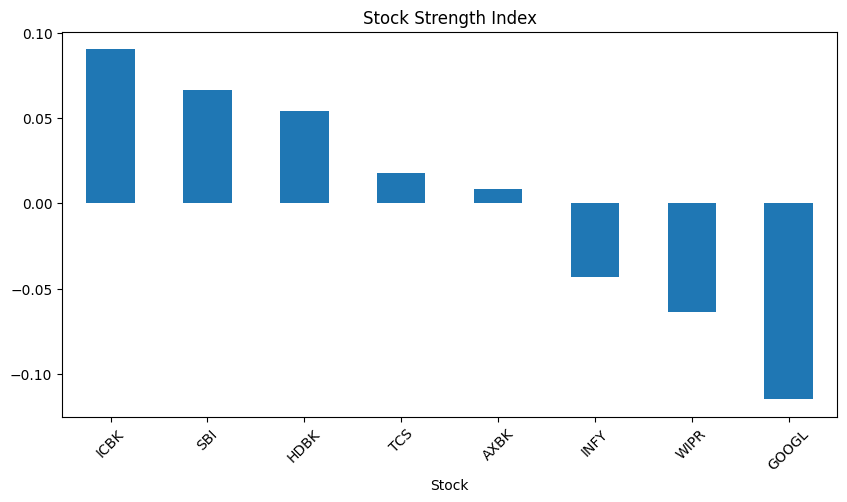

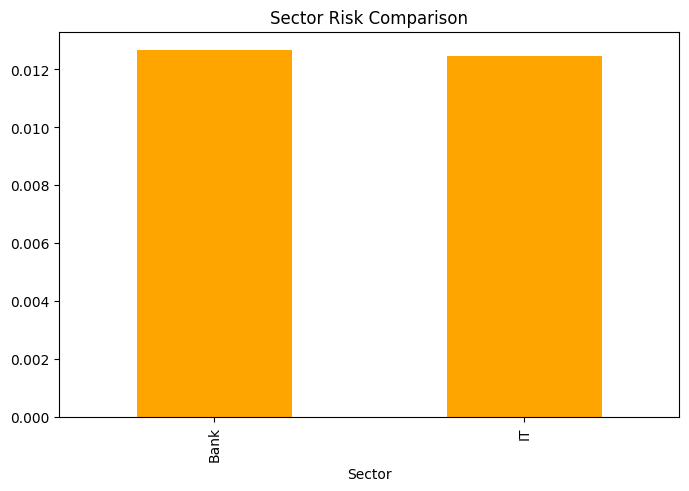


📌 NOTE:
This system provides analytical insights only.
No buy/sell signals are generated.
Final decision depends on user interpretation.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====================================================
#  CLEAN DATA
# =====================================================
df = df.sort_values(["Stock", "Date"]).dropna().reset_index(drop=True)

# =====================================================
#  SAFE FEATURE CREATION (IMPORTANT FIX)
# =====================================================

# Returns
if "Returns" not in df.columns:
    df["Returns"] = df.groupby("Stock")["Close"].pct_change()

# Volatility
if "Volatility" not in df.columns:
    df["Volatility"] = df.groupby("Stock")["Returns"].rolling(5).std().reset_index(0, drop=True)

# Sentiment
if "Sentiment" not in df.columns:
    df["Sentiment"] = 0

# News Count
if "News_Count" not in df.columns:
    df["News_Count"] = 0

# Fill remaining NaNs safely
df = df.fillna(0)

# =====================================================
#  NORMALIZATION
# =====================================================
df['Sentiment_Norm'] = (df['Sentiment'] - df['Sentiment'].mean()) / (df['Sentiment'].std() + 1e-6)
df['Returns_Norm'] = (df['Returns'] - df['Returns'].mean()) / (df['Returns'].std() + 1e-6)
df['Volatility_Norm'] = (df['Volatility'] - df['Volatility'].mean()) / (df['Volatility'].std() + 1e-6)
df['News_Norm'] = (df['News_Count'] - df['News_Count'].mean()) / (df['News_Count'].std() + 1e-6)

# =====================================================
#  INVESTMENT SCORE (EXPLAINABLE INDEX)
# =====================================================
df['Investment_Score'] = (
    df['Sentiment_Norm'] * 0.30 +
    df['Returns_Norm'] * 0.25 -
    df['Volatility_Norm'] * 0.25 +
    df['News_Norm'] * 0.10
)

# =====================================================
#  STOCK SUMMARY
# =====================================================
stock_summary = df.groupby('Stock').agg({
    'Investment_Score': 'mean',
    'Sentiment': 'mean',
    'Volatility': 'mean',
    'Returns': 'mean',
    'News_Count': 'mean'
}).sort_values(by='Investment_Score', ascending=False)

print("\n STOCK BEHAVIOUR SUMMARY\n")
print(stock_summary)

# =====================================================
#  INTERPRETATION ENGINE
# =====================================================
def interpret(row):

    sentiment = row['Sentiment']
    volatility = row['Volatility']
    returns = row['Returns']

    if sentiment > 0.2:
        mood = "Positive market sentiment"
    elif sentiment < -0.2:
        mood = "Negative market sentiment"
    else:
        mood = "Neutral market sentiment"

    if volatility < df['Volatility'].median():
        risk = "Lower risk (stable movement)"
    else:
        risk = "Higher risk (volatile movement)"

    if returns > 0:
        trend = "Upward momentum observed"
    else:
        trend = "Downward momentum observed"

    return f"{mood} | {risk} | {trend}"

# =====================================================
#  STOCK INSIGHTS
# =====================================================
print("\n📌 STOCK INSIGHTS\n")

for stock in stock_summary.index:
    row = df[df['Stock'] == stock].iloc[0]
    print(f"\n🔹 {stock}")
    print(interpret(row))

# =====================================================
# SECTOR ANALYSIS
# =====================================================
if "Sector" in df.columns:
    sector_summary = df.groupby('Sector')[['Volatility', 'Sentiment', 'Returns']].mean()

    print("\n🏦 SECTOR OVERVIEW\n")
    print(sector_summary)

    print("\n📌 SECTOR INSIGHTS\n")

    for sector in sector_summary.index:

        vol = sector_summary.loc[sector, 'Volatility']
        sent = sector_summary.loc[sector, 'Sentiment']

        risk = "relatively stable" if vol < df['Volatility'].median() else "more volatile"
        mood = "positive sentiment environment" if sent > 0 else "neutral/weak sentiment environment"

        print(f"{sector}: {risk}, {mood}")

# =====================================================
#  VISUALIZATION
# =====================================================
plt.figure(figsize=(10,5))
stock_summary['Investment_Score'].plot(kind='bar')
plt.title("Stock Strength Index")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
if "Sector" in df.columns:
    df.groupby('Sector')['Volatility'].mean().plot(kind='bar', color='orange')
    plt.title("Sector Risk Comparison")
    plt.show()

# =====================================================
#  FINAL NOTE
# =====================================================
print("\n📌 NOTE:")
print("This system provides analytical insights only.")
print("No buy/sell signals are generated.")
print("Final decision depends on user interpretation.")


📊 STOCK MARKET INTELLIGENCE DASHBOARD

🏆 TOP STOCKS

       Market_Health_Index  Trend_Strength  Volatility  Sentiment
Stock                                                            
SBI               1.140659        0.009671    0.012272   0.012573
ICBK              0.893514        0.005368    0.009933   0.005833
AXBK              0.848788        0.004946    0.012350   0.006378
HDBK              0.396503        0.002631    0.010406   0.004363
GOOGL             0.395940        0.013136    0.016159   0.002006
INFY              0.143111       -0.001270    0.013529   0.003066
WIPR              0.046310       -0.000150    0.014286   0.003579
TCS              -0.922910       -0.003750    0.011415   0.002151


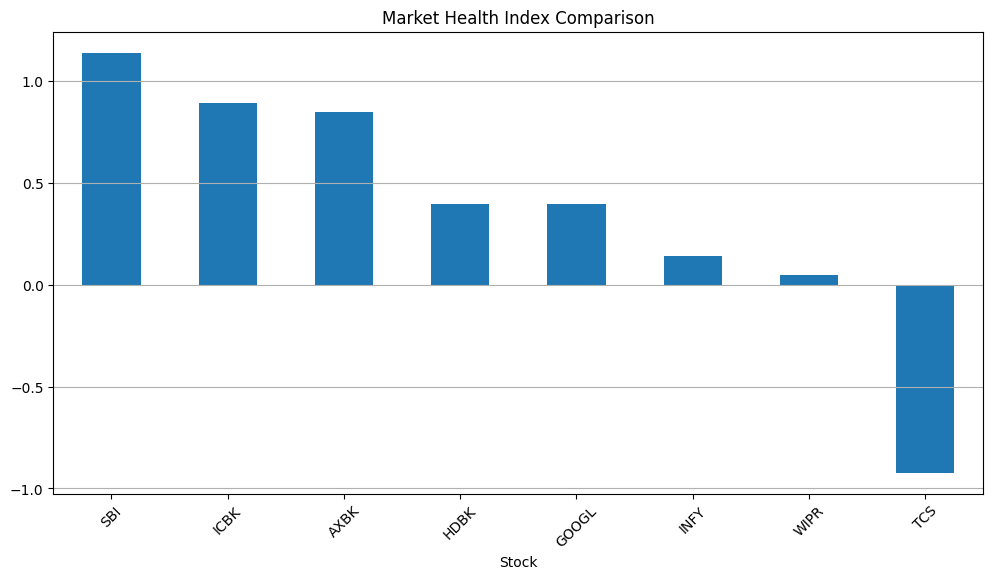

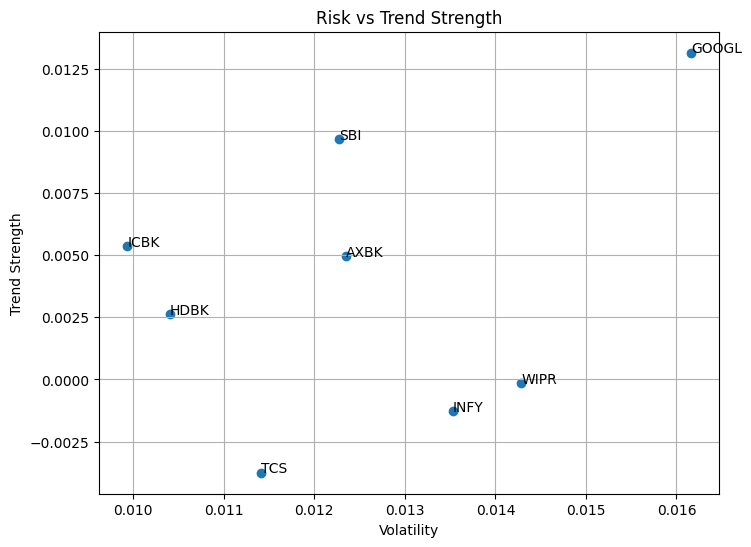

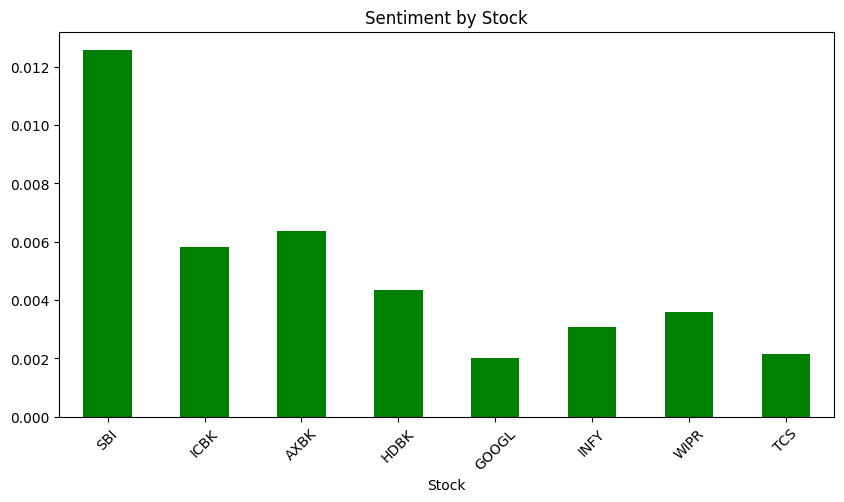


📌 FINAL INSIGHTS
🏆 Strongest Stock: SBI
⚠️ Weakest Stock: TCS

✔ Higher Trend Strength = stronger momentum
✔ Higher Volatility = unstable behavior
✔ Market Health Index = combined signal score


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 🧹 CLEAN DATA
# =====================================================
df = df.sort_values(["Stock", "Date"]).dropna().reset_index(drop=True)

# =====================================================
# 🔥 SAFE BASE FEATURES
# =====================================================
if "Returns" not in df.columns:
    df["Returns"] = df.groupby("Stock")["Close"].pct_change()

if "Volatility" not in df.columns:
    df["Volatility"] = df.groupby("Stock")["Returns"].rolling(5).std().reset_index(0, drop=True)

if "Sentiment" not in df.columns:
    df["Sentiment"] = 0

if "News_Count" not in df.columns:
    df["News_Count"] = 0

df = df.fillna(0)

# =====================================================
# 📊 ADVANCED METRICS (AUTO BUILD FIX)
# =====================================================

# Trend Strength
df["MA_10"] = df.groupby("Stock")["Close"].transform(lambda x: x.rolling(10).mean())
df["MA_30"] = df.groupby("Stock")["Close"].transform(lambda x: x.rolling(30).mean())
df["Trend_Strength"] = (df["MA_10"] - df["MA_30"]) / (df["Close"] + 1e-6)

# MACD
exp1 = df.groupby("Stock")["Close"].transform(lambda x: x.ewm(span=12).mean())
exp2 = df.groupby("Stock")["Close"].transform(lambda x: x.ewm(span=26).mean())
df["MACD"] = exp1 - exp2

# Downside Risk
df["Negative_Returns"] = df["Returns"].apply(lambda x: x if x < 0 else 0)
df["Downside_Risk"] = df.groupby("Stock")["Negative_Returns"].transform("std")

# Attention Score
df["Attention_Score"] = df["News_Count"] / (df["Volume"] + 1e-6)

# Efficiency Ratio
df["Price_Change"] = df.groupby("Stock")["Close"].transform(lambda x: x.diff().abs())
df["Efficiency_Ratio"] = df["Returns"].abs() / (df["Price_Change"] + 1e-6)

# Market Health Index
df["Market_Health_Index"] = (
    df["Trend_Strength"] * 0.25 +
    df["MACD"] * 0.20 +
    df["Sentiment"] * 0.20 -
    df["Volatility"] * 0.20 -
    df["Downside_Risk"] * 0.15
)

# =====================================================
# 📊 DASHBOARD SUMMARY (SAFE GROUPBY)
# =====================================================
dashboard = df.groupby("Stock").mean(numeric_only=True)

dashboard = dashboard.sort_values(
    by="Market_Health_Index",
    ascending=False
)

# =====================================================
# 📊 PRINT DASHBOARD TABLE
# =====================================================
print("\n" + "="*70)
print("📊 STOCK MARKET INTELLIGENCE DASHBOARD")
print("="*70)

print("\n🏆 TOP STOCKS\n")
print(dashboard[["Market_Health_Index", "Trend_Strength", "Volatility", "Sentiment"]].head(10))

# =====================================================
# 📈 MARKET HEALTH INDEX PLOT
# =====================================================
plt.figure(figsize=(12,6))
dashboard["Market_Health_Index"].plot(kind="bar")
plt.title("Market Health Index Comparison")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

# =====================================================
# ⚡ RISK vs TREND
# =====================================================
plt.figure(figsize=(8,6))
plt.scatter(dashboard["Volatility"], dashboard["Trend_Strength"])

for i, stock in enumerate(dashboard.index):
    plt.annotate(stock,
                 (dashboard["Volatility"].iloc[i],
                  dashboard["Trend_Strength"].iloc[i]))

plt.title("Risk vs Trend Strength")
plt.xlabel("Volatility")
plt.ylabel("Trend Strength")
plt.grid()
plt.show()

# =====================================================
# 💬 SENTIMENT PLOT
# =====================================================
plt.figure(figsize=(10,5))
dashboard["Sentiment"].plot(kind="bar", color="green")
plt.title("Sentiment by Stock")
plt.xticks(rotation=45)
plt.show()

# =====================================================
# 🧠 FINAL INSIGHTS
# =====================================================
print("\n📌 FINAL INSIGHTS")
print("="*70)

best = dashboard["Market_Health_Index"].idxmax()
worst = dashboard["Market_Health_Index"].idxmin()

print(f"🏆 Strongest Stock: {best}")
print(f"⚠️ Weakest Stock: {worst}")

print("\n✔ Higher Trend Strength = stronger momentum")
print("✔ Higher Volatility = unstable behavior")
print("✔ Market Health Index = combined signal score")